In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

sns.set_style("whitegrid")

DATA = Path("../data/processed")

In [11]:
fund_master = pd.read_csv(DATA/"01_fund_master_cleaned.csv")

nav = pd.read_csv(DATA/"02_nav_history_cleaned.csv")

aum = pd.read_csv(DATA/"03_aum_by_fund_house_cleaned.csv")

sip = pd.read_csv(DATA/"04_monthly_sip_inflows_cleaned.csv")

cat = pd.read_csv(DATA/"05_category_inflows_cleaned.csv")

folios = pd.read_csv(DATA/"06_industry_folio_count_cleaned.csv")

perf = pd.read_csv(DATA/"07_scheme_performance_cleaned.csv")

txn = pd.read_csv(DATA/"08_investor_transactions_cleaned.csv")

holdings = pd.read_csv(DATA/"09_portfolio_holdings_cleaned.csv")

bench = pd.read_csv(DATA/"10_benchmark_indices_cleaned.csv")

In [12]:
print("Fund Master:", fund_master.shape)
print("NAV:", nav.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Transactions:", txn.shape)

Fund Master: (40, 15)
NAV: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Transactions: (32778, 13)


In [13]:
nav["date"] = pd.to_datetime(nav["date"])
print(nav.head())

   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639


In [14]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trends for All Mutual Fund Schemes (2022-2026)"
)

fig.show()

## Insight 1

Most mutual fund schemes show a steady upward NAV trend between 2022 and 2025, indicating overall market growth and positive investor returns

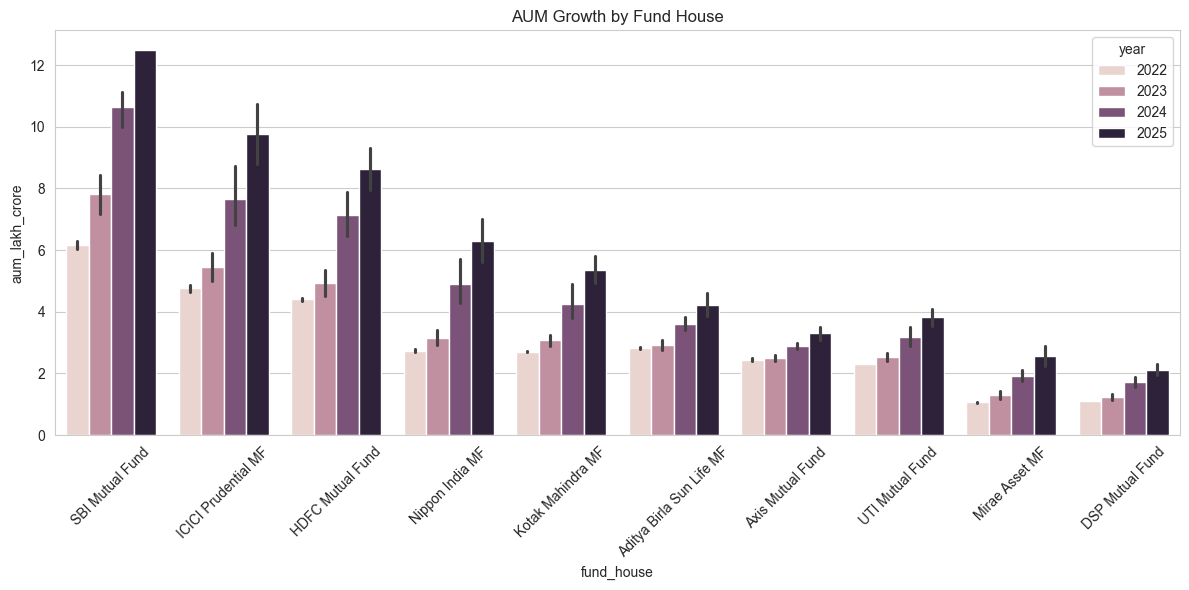

In [ ]:
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.xticks(rotation=45)
plt.title("AUM Growth by Fund House")
plt.tight_layout()
plt.show()

## Insight 2

SBI Mutual Fund consistently maintains the highest Assets Under Management (AUM) across the study period

In [ ]:
sip["month"] = pd.to_datetime(sip["month"])
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows (2022-2025)"
)
fig.show()

## Insight 3
Monthly SIP inflows show a strong upward trend, indicating increasing retail participation in mutual funds

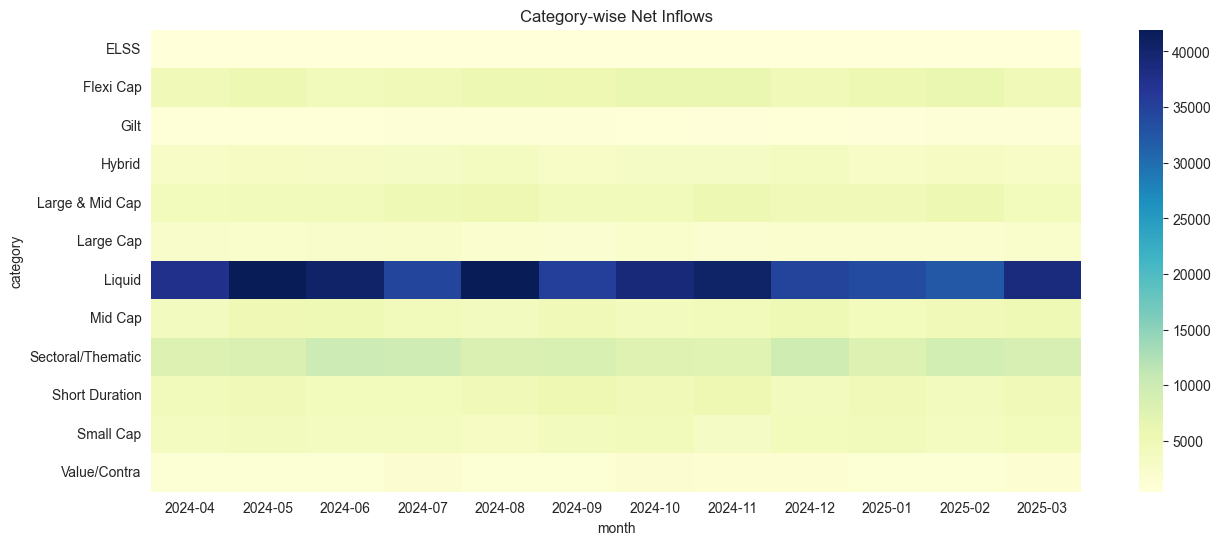

In [16]:
pivot = cat.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)
plt.figure(figsize=(15,6))
sns.heatmap(
    pivot,
    cmap="YlGnBu"
)
plt.title("Category-wise Net Inflows")
plt.show()

## Insight 4

Large Cap, Flexi Cap, and Mid Cap categories attracted substantial investor inflows during several periods

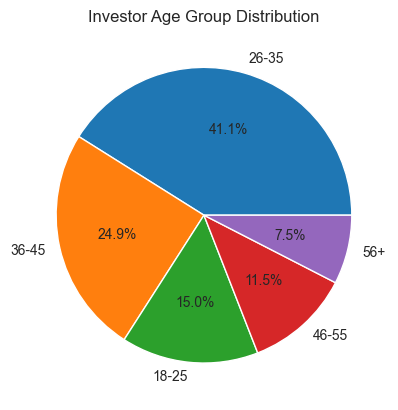

In [18]:
txn["age_group"].value_counts().plot.pie(
    autopct="%1.1f%%"
)
plt.ylabel("")
plt.title("Investor Age Group Distribution")
plt.show()

## Insight 5

Investors in the working-age population contribute the largest share of transactions

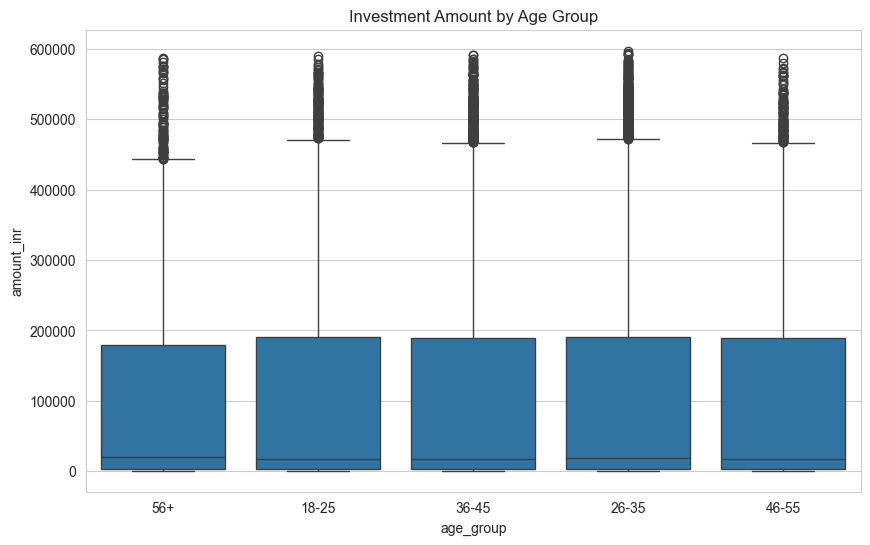

In [19]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=txn,
    x="age_group",
    y="amount_inr"
)
plt.title("Investment Amount by Age Group")
plt.show()

## Insight 6

Investment amounts vary significantly across age groups, with some groups showing higher median investments

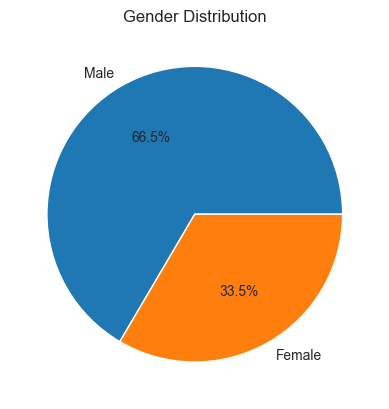

In [20]:
txn["gender"].value_counts().plot.pie(
    autopct="%1.1f%%"
)
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

## Insight 7

Male investors slightly outnumber female investors in the transaction dataset

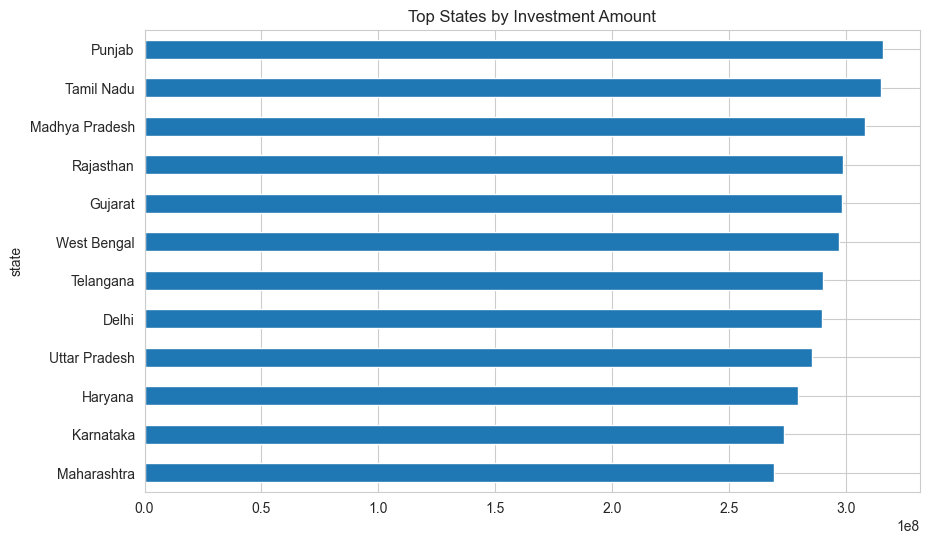

In [21]:
state_amount = txn.groupby("state")["amount_inr"].sum()
state_amount.sort_values().tail(15).plot.barh(
    figsize=(10,6)
)
plt.title("Top States by Investment Amount")
plt.show()

## Insight 8

A few states contribute a disproportionately large share of total investments

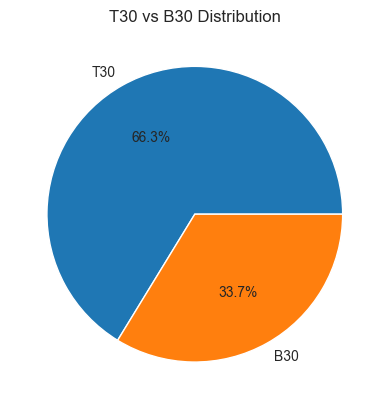

In [22]:
txn["city_tier"].value_counts().plot.pie(
    autopct="%1.1f%%"
)
plt.title("T30 vs B30 Distribution")
plt.ylabel("")
plt.show()

## Insight 9

T30 cities contribute a majority of investments compared to B30 cities.

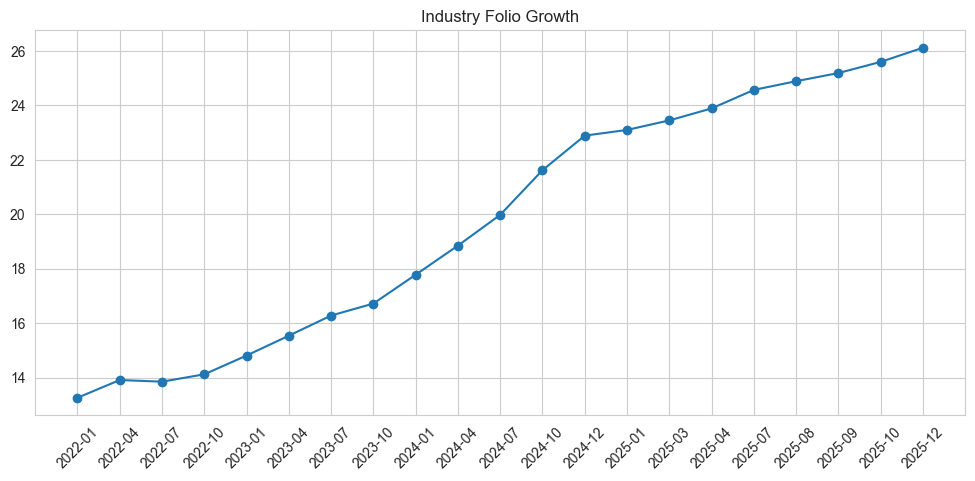

In [25]:
plt.figure(figsize=(12,5))
plt.plot(
    folios["month"],
    folios["total_folios_crore"],
    marker="o"
)
plt.xticks(rotation=45)
plt.title("Industry Folio Growth")
plt.show()

## Insight 10

Industry folio count shows strong growth between 2022 and 2025

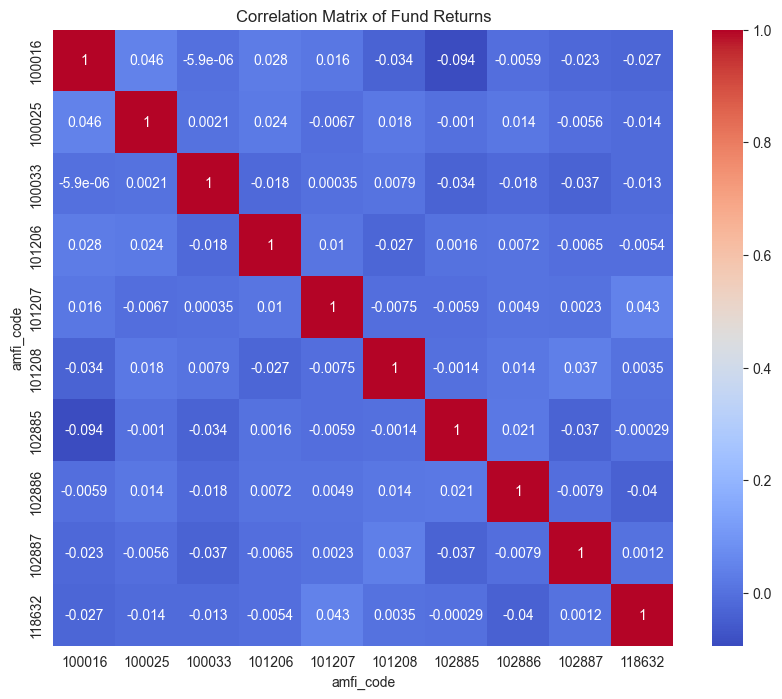

In [26]:
selected_funds = nav["amfi_code"].unique()[:10]
corr_df = nav[
    nav["amfi_code"].isin(selected_funds)
]
pivot = corr_df.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)
returns = pivot.pct_change()
corr_matrix = returns.corr()
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix of Fund Returns")
plt.show()

## Insight 11

Most mutual fund schemes exhibit positive return correlations, indicating that market-wide movements influence fund performance across categories.

In [27]:
sector_weights = holdings.groupby("sector")["weight_pct"].sum()
fig = px.pie(
    names=sector_weights.index,
    values=sector_weights.values,
    hole=0.5,
    title="Sector Allocation Across Equity Funds"
)
fig.show()

## Insight 12

Financial Services and Technology sectors account for a significant share of mutual fund portfolios

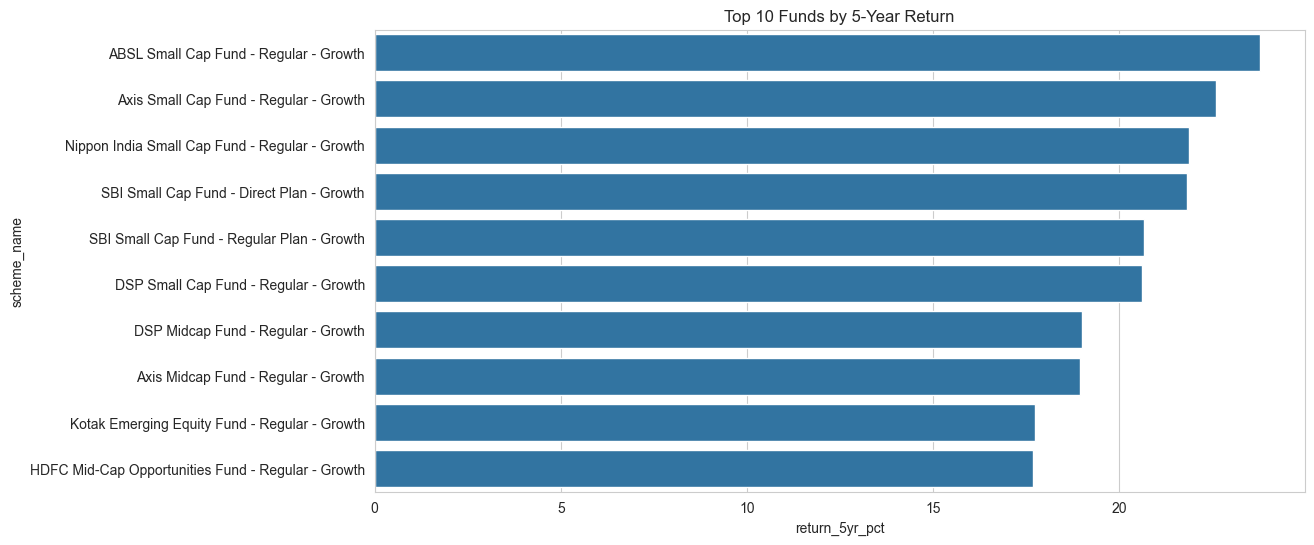

In [28]:
top_returns = perf.sort_values(
    "return_5yr_pct",
    ascending=False
).head(10)
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_returns,
    x="return_5yr_pct",
    y="scheme_name"
)
plt.title("Top 10 Funds by 5-Year Return")
plt.show()

## Insight 13

A small group of funds consistently outperformed peers based on 5-year returns

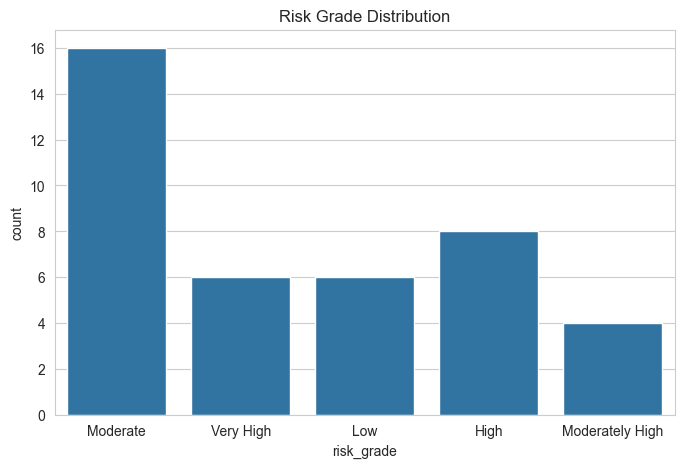

In [29]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=perf,
    x="risk_grade"
)
plt.title("Risk Grade Distribution")
plt.show()

## Insight 14

Most equity-oriented schemes fall under High or Very High risk categories

In [30]:
print(txn.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')


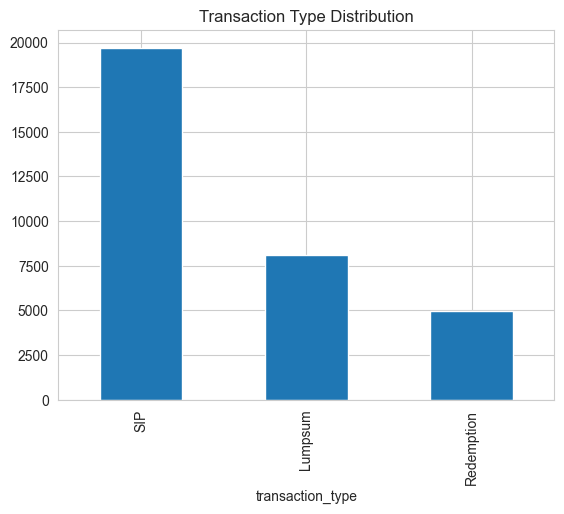

In [31]:
txn["transaction_type"].value_counts().plot.bar()
plt.title("Transaction Type Distribution")
plt.show()

## Insight 15

SIP transactions form a major portion of investor activity, highlighting systematic investing behaviour

# EDA Summary

This exploratory analysis identified strong SIP growth, rising industry folios, increasing mutual fund participation, concentration of AUM among leading fund houses, and strong positive correlations among fund returns. Investor activity is concentrated in working-age groups and major urban centres, while equity portfolios are heavily allocated towards Financial Services and Technology sectors.